# UTCI → horas anuales por nivel de estrés térmico (México 2023)

Lee el crudo `data/raw/UTCI/2023/UTCI_Mexico_2023.nc` (horario, 8760 pasos),
clasifica cada hora en uno de los 10 niveles de estrés de la escala UTCI
(ISB) y cuenta, para cada punto de malla, cuántas horas del año caen en cada
nivel. Guarda `data/raw/UTCI/2023/UTCI_levels_2023.nc` con
`hours(level, lat, lon)`.

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr

YEAR = 2023
ROOT = Path("..").resolve()          # repo (la libreta vive en notebooks/)
RAW_DIR = ROOT / "data" / "raw" / "UTCI" / str(YEAR)
IN_FILE = RAW_DIR / f"UTCI_Mexico_{YEAR}.nc"
OUT_FILE = RAW_DIR / f"UTCI_levels_{YEAR}.nc"

# Umbrales de la escala UTCI (°C): 9 cortes → 10 niveles
BOUNDS = [-40.0, -27.0, -13.0, 0.0, 9.0, 26.0, 32.0, 38.0, 46.0]
LEVEL_NAMES = [
    "extreme cold stress",        # < -40
    "very strong cold stress",    # -40 .. -27
    "strong cold stress",         # -27 .. -13
    "moderate cold stress",       # -13 .. 0
    "slight cold stress",         # 0 .. 9
    "no thermal stress",          # 9 .. 26
    "moderate heat stress",       # 26 .. 32
    "strong heat stress",         # 32 .. 38
    "very strong heat stress",    # 38 .. 46
    "extreme heat stress",        # > 46
]
LEVEL_NAMES_ES = [
    "estrés por frío extremo",
    "estrés por frío muy fuerte",
    "estrés por frío fuerte",
    "estrés por frío moderado",
    "estrés por frío ligero",
    "sin estrés térmico",
    "estrés por calor moderado",
    "estrés por calor fuerte",
    "estrés por calor muy fuerte",
    "estrés por calor extremo",
]

In [2]:
ds = xr.open_dataset(IN_FILE)
utci = ds["utci"]
print(ds)

# El archivo viene en °C; si algún año llegara en Kelvin, convertimos
if float(utci.max()) > 100:
    utci = utci - 273.15
    print("Convertido de K a °C")
print("Rango UTCI (°C):", float(utci.min()), "→", float(utci.max()))
print("Horas:", utci.sizes["time"])

<xarray.Dataset> Size: 363MB
Dimensions:  (time: 8760, lat: 79, lon: 131)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2023-01-01 ... 2023-12-31T23:00:00
  * lat      (lat) float64 632B 33.5 33.25 33.0 32.75 ... 14.75 14.5 14.25 14.0
  * lon      (lon) float64 1kB -118.5 -118.2 -118.0 ... -86.5 -86.25 -86.0
Data variables:
    utci     (time, lat, lon) float32 363MB ...
Attributes:
    CDI:                       Climate Data Interface version 1.9.10 (https:/...
    Conventions:               CF-1.6
    institution:               European Centre for Medium-Range Weather Forec...
    CDO:                       Climate Data Operators version 1.9.10 (https:/...
    cdo_openmp_thread_number:  8
    history:                   Wed Apr 26 11:35:18 2023: ncatted -a _FillValu...
    NCO:                       netCDF Operators version 4.9.7 (Homepage = htt...
Rango UTCI (°C): -37.86927795410156 → 53.8572998046875
Horas: 8760


In [3]:
# np.digitize asigna: nivel k si BOUNDS[k-1] <= x < BOUNDS[k]
idx = xr.apply_ufunc(np.digitize, utci, kwargs={"bins": BOUNDS}).astype("int8")
# Los NaN caen en el último bin de digitize; los marcamos con -1
idx = idx.where(utci.notnull(), -1)

In [4]:
hours = xr.concat(
    [(idx == k).sum("time", dtype="int32") for k in range(10)],
    dim="level",
).assign_coords(level=np.arange(10, dtype="int8"))
hours.name = "hours"

In [5]:
total = hours.sum("level")
n_horas = utci.sizes["time"]
ok = bool((total == n_horas).all())
print(f"Suma sobre niveles == {n_horas} en todos los puntos: {ok}")
if not ok:
    # El crudo trae NaN donde el UTCI es indefinido (viento fuera del rango de
    # validez de la fórmula; p.ej. los jets del Golfo de Tehuantepec). Esas
    # horas no se clasifican: la suma queda < 8760 en esos puntos.
    bad = int((total != n_horas).sum())
    print(f"  Puntos con horas faltantes: {bad} de {total.size}")
    print("  Mínimo de horas clasificadas en un punto:", int(total.min()))

Suma sobre niveles == 8760 en todos los puntos: False
  Puntos con horas faltantes: 2971 de 10349
  Mínimo de horas clasificadas en un punto: 8401


In [6]:
tot = float(hours.sum())
for k in range(10):
    pct = 100 * float(hours.sel(level=k).sum()) / tot
    print(f"nivel {k} — {LEVEL_NAMES_ES[k]:<28s} {pct:6.2f} %")

nivel 0 — estrés por frío extremo        0.00 %
nivel 1 — estrés por frío muy fuerte     0.00 %
nivel 2 — estrés por frío fuerte         0.18 %
nivel 3 — estrés por frío moderado       2.98 %
nivel 4 — estrés por frío ligero         8.54 %
nivel 5 — sin estrés térmico            50.28 %
nivel 6 — estrés por calor moderado     24.88 %
nivel 7 — estrés por calor fuerte       10.82 %
nivel 8 — estrés por calor muy fuerte    2.25 %
nivel 9 — estrés por calor extremo       0.07 %


In [7]:
out = hours.to_dataset()
out["hours"].attrs = {
    "long_name": "annual hours per UTCI thermal stress level",
    "units": "h",
    "valid_range": [0, n_horas],
}
out["valid_hours"] = total.astype("int32")
out["valid_hours"].attrs = {
    "long_name": "hours with valid (classifiable) UTCI in the year",
    "units": "h",
    "comment": ("< 8760 donde el crudo trae NaN (UTCI indefinido, "
                "p.ej. viento fuera de rango sobre océano)"),
}
out["level"].attrs = {
    "long_name": "UTCI thermal stress level",
    "flag_values": list(range(10)),
    "flag_meanings": " ".join(n.replace(" ", "_") for n in LEVEL_NAMES),
    "names_es": "; ".join(LEVEL_NAMES_ES),
}
out.attrs = {
    "title": f"UTCI annual hours per thermal stress level, Mexico {YEAR}",
    "source_file": IN_FILE.name,
    "utci_bounds_degC": BOUNDS,
    "classification": "ISB UTCI assessment scale, 10 levels",
    "institution": "IER-UNAM",
    "history": f"generated by notebooks/002_UTCI_levels.ipynb from {IN_FILE.name}",
}
print(out)

<xarray.Dataset> Size: 457kB
Dimensions:      (lon: 131, lat: 79, level: 10)
Coordinates:
  * lon          (lon) float64 1kB -118.5 -118.2 -118.0 ... -86.5 -86.25 -86.0
  * lat          (lat) float64 632B 33.5 33.25 33.0 32.75 ... 14.5 14.25 14.0
  * level        (level) int8 10B 0 1 2 3 4 5 6 7 8 9
Data variables:
    hours        (level, lat, lon) int32 414kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    valid_hours  (lat, lon) int32 41kB 8758 8758 8760 8760 ... 8760 8760 8760
Attributes:
    title:             UTCI annual hours per thermal stress level, Mexico 2023
    source_file:       UTCI_Mexico_2023.nc
    utci_bounds_degC:  [-40.0, -27.0, -13.0, 0.0, 9.0, 26.0, 32.0, 38.0, 46.0]
    classification:    ISB UTCI assessment scale, 10 levels
    institution:       IER-UNAM
    history:           generated by notebooks/002_UTCI_levels.ipynb from UTCI...


In [8]:
encoding = {"hours": {"zlib": True, "complevel": 4}}
out.to_netcdf(OUT_FILE, encoding=encoding)
print("Guardado:", OUT_FILE, f"({OUT_FILE.stat().st_size / 1e6:.1f} MB)")

Guardado: /Users/gbv/atlas/data/raw/UTCI/2023/UTCI_levels_2023.nc (0.1 MB)


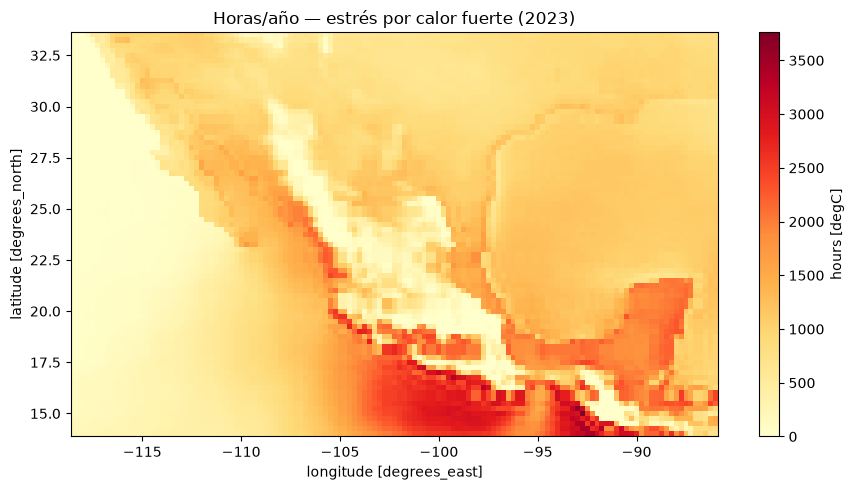

In [9]:
import matplotlib.pyplot as plt

k = 7  # estrés por calor fuerte
fig, ax = plt.subplots(figsize=(9, 5))
hours.sel(level=k).plot(ax=ax, cmap="YlOrRd")
ax.set_title(f"Horas/año — {LEVEL_NAMES_ES[k]} ({YEAR})")
plt.tight_layout()
plt.show()